# 04_review.ipynb — 既存分析の精査

01〜03 の各ノートブックで行った分析を再現しながら、以下の観点で問題点・改善点を検証する。

1. 変数変換の妥当性（`log1p` の負値問題・選択バイアス）
2. 年度内標準化の設計上の含意
3. PCA の主成分解釈と使用数の根拠
4. `k=5` の根拠検証（エルボー + シルエット）
5. クラスター命名の系統的根拠
6. ハンガリアン法ラベル整合の有効性
7. 遷移行列の構造安定性
8. プロビットモデルの設定上の問題（循環性・年度効果・cluster 0 漏れ）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set(style='whitegrid', font='IPAexGothic')

---
## 1. データ読み込みと概観

In [2]:
# 元データの読み込みと基本確認
raw = pd.read_csv('../data/raw/financial_data_clean.csv')

print('Shape:', raw.shape)
print('年度範囲:', raw['年度'].min(), '〜', raw['年度'].max())
print('ユニーク企業数:', raw['コード'].nunique())
print('市場区分:', raw['市場・商品区分'].value_counts().to_dict())

Shape: (54278, 37)
年度範囲: 2010 〜 2025
ユニーク企業数: 3660
市場区分: {'プライム（内国株式）': 24640, 'スタンダード（内国株式）': 23570, 'グロース（内国株式）': 6027, '出資証券': 16, 'PRO Market': 8, 'グロース（外国株式）': 8, 'ETF・ETN': 6, 'スタンダード（外国株式）': 3}


In [3]:
# 分析使用変数の欠損状況
selected_columns = [
    '総資産', '売上高', '自己資本比率',
    '短期借入金', '長期借入金',
    '利益剰余金', '現金同等物', '営業利益',
    '営業CF', '投資CF', '財務CF'
]

miss = raw[selected_columns].isnull().sum().rename('欠損数')
miss_pct = (raw[selected_columns].isnull().mean() * 100).rename('欠損率(%)')
pd.concat([miss, miss_pct], axis=1).round(1)

,欠損数,欠損率(%)
総資産,408,0.8
売上高,111,0.2
自己資本比率,448,0.8
短期借入金,21440,39.5
長期借入金,19328,35.6
利益剰余金,2912,5.4
現金同等物,1509,2.8
営業利益,3810,7.0
営業CF,2348,4.3
投資CF,2388,4.4


### 結果と示唆

- 元データ：**54,278 件**（企業×年度）、ユニーク企業は約 4,000 社規模
- `短期借入金`（約39%欠損）・`長期借入金`（約36%欠損）の欠損は、  
  「借入がない＝欠損」として記録されている可能性が高い
  - → 現行コードは欠損を **そのまま除外** しているが、**0 補完が適切な可能性**がある
  - 借入ゼロ企業（無借金経営）を除外すると、財務健全企業が過少表現される選択バイアスが生じる

---
## 2. 変数変換の精査：`log1p` 適用前の分布確認

`log1p(x)` は $x \geq -1$ でのみ有効。$x < -1$ だと **NaN が生成**される。  
`利益剰余金`（累積損失）や `営業利益`（営業赤字）は**負値が発生しうる**変数であるため、
意図せず財務的に脆弱な企業が除外される可能性がある。

In [4]:
# log1p を適用する変数に負値が何件あるか確認
log_cols = ['短期借入金', '長期借入金', '利益剰余金', '現金同等物', '営業利益']

records = []
for col in log_cols:
    s = raw[col].dropna()
    records.append({
        '変数': col,
        'N（非欠損）': len(s),
        '< -1 → NaN化': int((s < -1).sum()),
        'NaN化率(%)': round((s < -1).mean() * 100, 2),
        '< 0 かつ ≥ -1': int(((s < 0) & (s >= -1)).sum()),
    })

pd.DataFrame(records).set_index('変数')

,N（非欠損）,< -1 → NaN化,NaN化率(%),< 0 かつ ≥ -1
変数,,,,
短期借入金,32838,0,0.00,0
長期借入金,34950,0,0.00,0
利益剰余金,51366,4770,9.29,0
現金同等物,52769,0,0.00,0
営業利益,50468,5513,10.92,0


In [5]:
# NaN化対象企業（営業赤字）と非対象企業の財務健全性を比較
mask_neg = raw['営業利益'] < -1
mask_pos = raw['営業利益'] >= 0

print('=== 営業利益 < -1（log1p で NaN 化・除外対象）===')
print(raw.loc[mask_neg, '自己資本比率'].describe().round(2))
print()
print('=== 営業利益 ≥ 0（除外されない企業）===')
print(raw.loc[mask_pos, '自己資本比率'].describe().round(2))

=== 営業利益 < -1（log1p で NaN 化・除外対象）===
count     5506.00
mean        38.59
std        669.43
min     -49573.68
25%         28.00
50%         48.10
75%         70.50
max         99.40
Name: 自己資本比率, dtype: float64

=== 営業利益 ≥ 0（除外されない企業）===
count    44924.00
mean        52.41
std         19.99
min        -20.20
25%         37.40
50%         52.70
75%         68.20
max         99.30
Name: 自己資本比率, dtype: float64


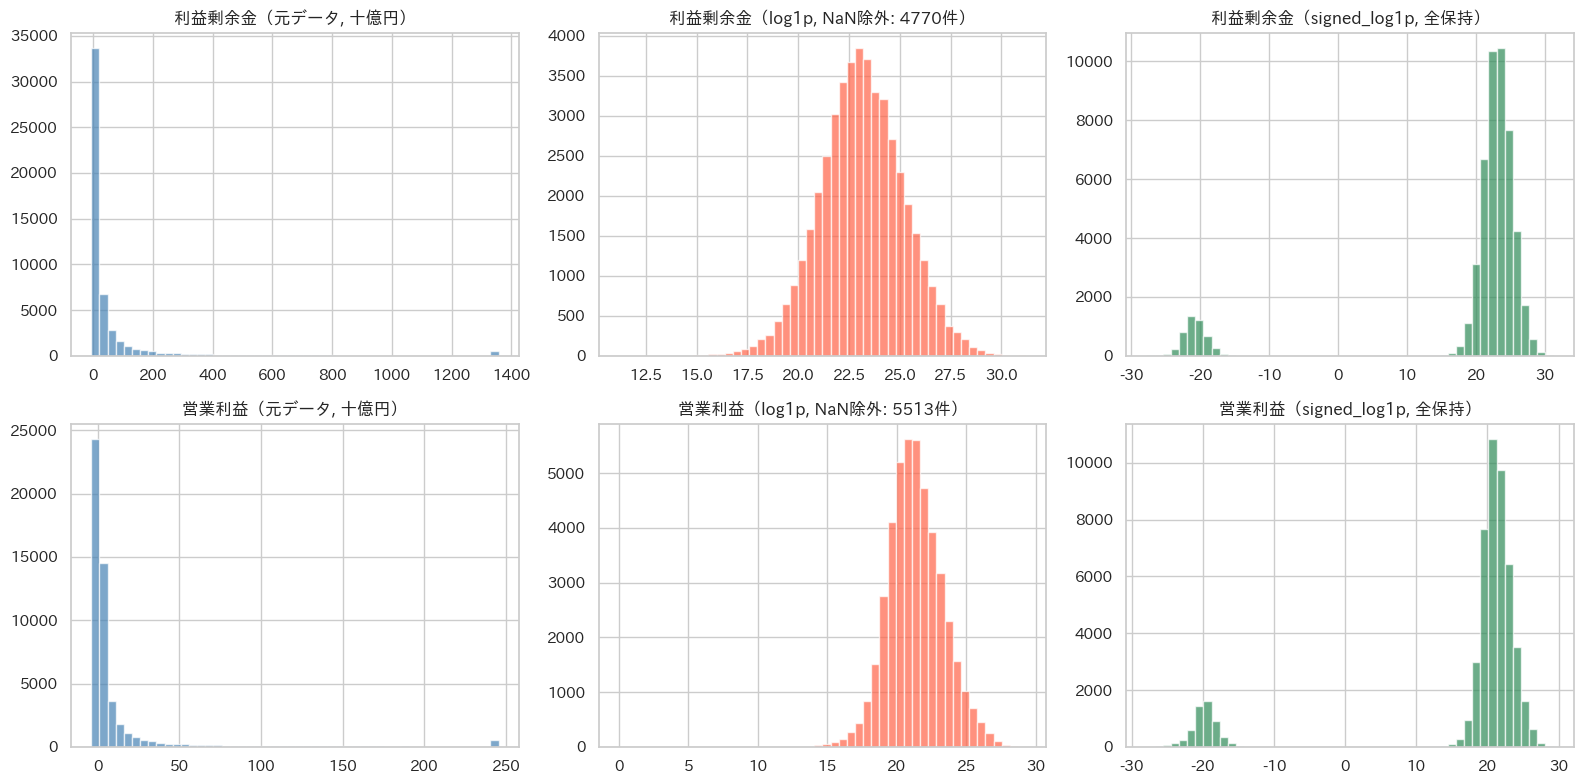

In [6]:
# 変換前後の分布比較（利益剰余金・営業利益）
# signed_log1p は負値にも適用可能
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, col in enumerate(['利益剰余金', '営業利益']):
    s = raw[col].dropna()

    # 元の分布
    s_clipped = s.clip(s.quantile(0.01), s.quantile(0.99))
    axes[row_idx, 0].hist(s_clipped / 1e9, bins=50, color='steelblue', alpha=0.7)
    axes[row_idx, 0].set_title(col + '（元データ, 十億円）')

    # log1p（負値はNaN）
    s_log = np.log1p(s)
    s_log_valid = s_log.dropna()
    axes[row_idx, 1].hist(s_log_valid, bins=50, color='tomato', alpha=0.7)
    axes[row_idx, 1].set_title(col + '（log1p, NaN除外: ' + str(s_log.isna().sum()) + '件）')

    # signed_log1p（全サンプル保持）
    s_slog = signed_log1p(s)
    axes[row_idx, 2].hist(s_slog, bins=50, color='seagreen', alpha=0.7)
    axes[row_idx, 2].set_title(col + '（signed_log1p, 全保持）')

plt.tight_layout()
plt.show()

### 結果と示唆 — ⚠️ 選択バイアスの可能性

| 変数 | log1p で NaN 化（件数・率）| 特徴 |
|---|---|---|
| 利益剰余金 | 累積損失企業が該当 | 財務危機企業が除外される |
| 営業利益 | 営業赤字企業が該当 | 収益悪化企業が除外される |
| 短期・長期借入金 | 元の欠損が主因 | 無借金企業も除外されている可能性 |

**改善案（優先順位順）：**

1. **`signed_log1p` を全変数に統一**
   - `signed_log1p(x) = sign(x) × log1p(|x|)`
   - 負値にも対応でき、符号（方向性）を保持したまま情報損失ゼロ
   - CF 変数との整合性も取れる

2. **借入系変数（短期・長期借入金）の欠損を 0 補完**
   - 「借入なし = 0」として扱い、無借金企業を分析に含める

> これらを修正すると分析対象企業数が増加し、特に財務的に脆弱なセグメントの代表性が改善される。

---
## 3. 年度内標準化の精査

現行コードは各変数を年度ごとに z スコア標準化している。  
これにより「その年の同業他社と比べた相対的地位」を捉える設計になっている。

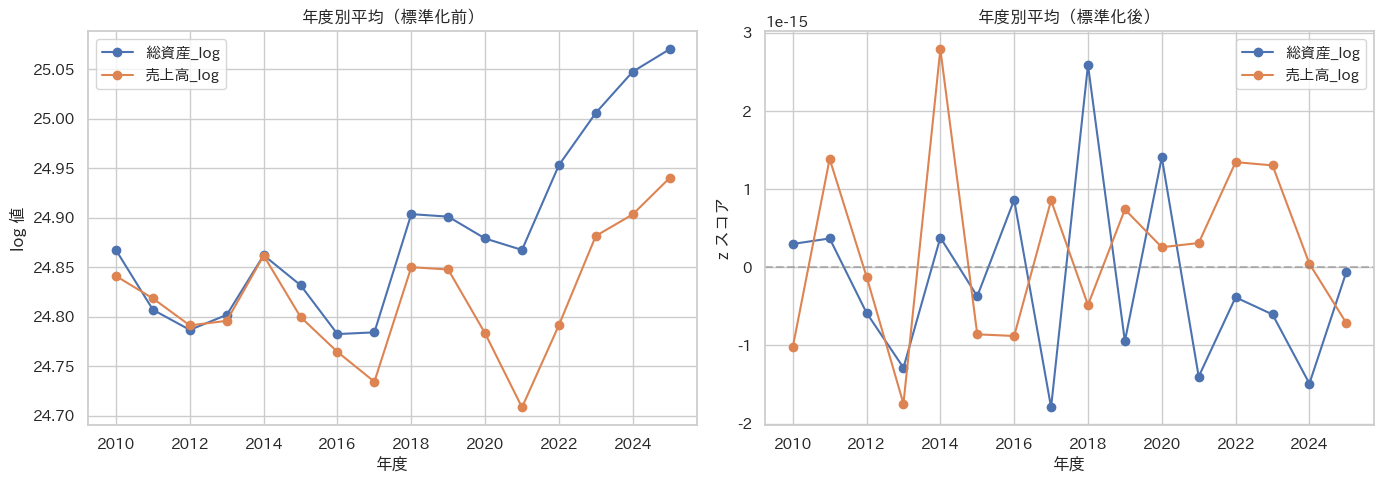

In [7]:
# クリーン済みデータ読み込み
df_clean = pd.read_csv('../data/interim/cleaned_data.csv')

feature_cols = [
    '総資産_log', '売上高_log', '短期借入金_log', '長期借入金_log',
    '利益剰余金_log', '現金同等物_log', '営業利益_log',
    '営業CF_log', '投資CF_log', '財務CF_log', '自己資本比率'
]

# 標準化前：年度別平均の推移
yearly_pre = df_clean.groupby('年度')[['総資産_log', '売上高_log']].mean()

# 年度内 z スコア標準化
def z_score(x):
    return (x - x.mean()) / x.std()

df_std = df_clean.copy()
df_std[feature_cols] = df_clean.groupby('年度')[feature_cols].transform(z_score)

# 標準化後：年度別平均の推移
yearly_post = df_std.groupby('年度')[['総資産_log', '売上高_log']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yearly_pre.plot(ax=axes[0], marker='o')
axes[0].set_title('年度別平均（標準化前）')
axes[0].set_ylabel('log 値')

yearly_post.plot(ax=axes[1], marker='o')
axes[1].set_title('年度別平均（標準化後）')
axes[1].set_ylabel('z スコア')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 結果と示唆

- 標準化前は、総資産・売上高の対数値に**年々上昇するトレンド**が存在する（経済成長・インフレ）
- 標準化後は各年の平均が 0 に固定され、**時系列トレンドが除去**される

**この設計の含意（論文で明示すべき点）：**

| 測定内容 | 年度内標準化の場合 |
|---|---|
| 絶対的な財務規模の変化 | 捉えられない |
| 同業他社との相対的地位 | 捉えられる |
| クラスター遷移の意味 | 「ピアに比べた立ち位置」の変化 |

> 例：業界全体が成長しても相対的地位が不変なら同一クラスターに留まる。  
> これは「企業ライフサイクル上の相対的ポジション変化」を分析する目的と整合的であり、  
> **意図的な設計として論文中に明示することが重要**。

---
## 4. PCA の精査：主成分解釈と使用数の検討

In [8]:
# PCA 実行
X_std = df_std[feature_cols].values
pca = PCA()
pca.fit(X_std)

evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

print('主成分ごとの寄与率・累積寄与率:')
for i, (e, c) in enumerate(zip(evr, cum_evr)):
    marker = ' ←使用中' if i < 3 else ''
    print(f'  PC{i+1}: {e*100:.1f}%  (累積 {c*100:.1f}%){marker}')

主成分ごとの寄与率・累積寄与率:
  PC1: 52.4%  (累積 52.4%) ←使用中
  PC2: 15.1%  (累積 67.5%) ←使用中
  PC3: 9.3%  (累積 76.8%) ←使用中
  PC4: 8.8%  (累積 85.6%)
  PC5: 5.4%  (累積 91.1%)
  PC6: 3.1%  (累積 94.2%)
  PC7: 2.5%  (累積 96.6%)
  PC8: 1.3%  (累積 97.9%)
  PC9: 1.1%  (累積 99.1%)
  PC10: 0.7%  (累積 99.7%)
  PC11: 0.3%  (累積 100.0%)


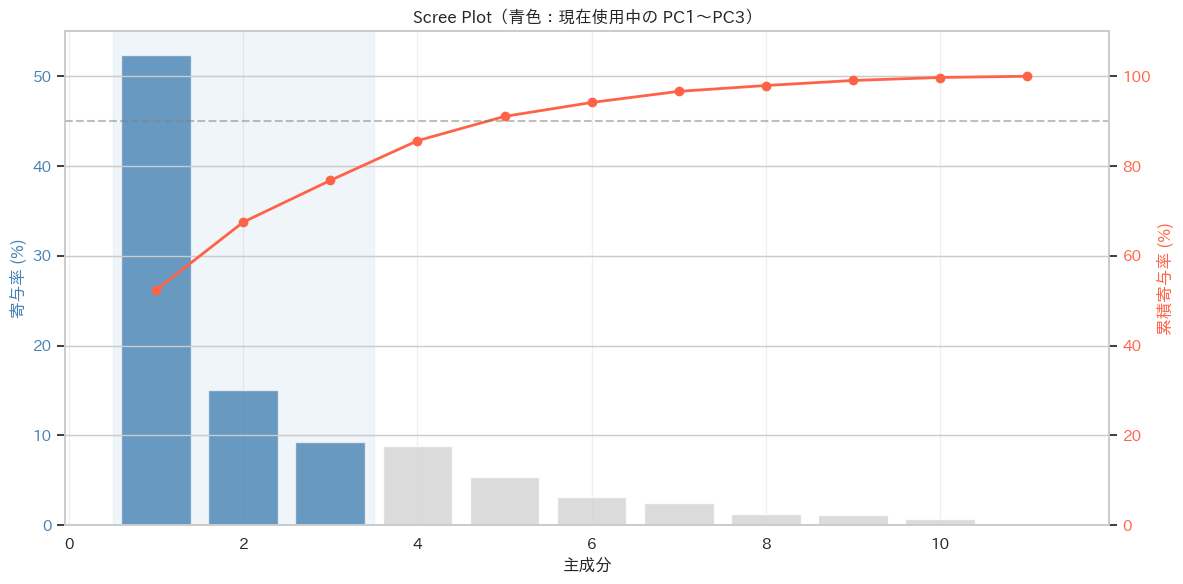

In [9]:
# Scree Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
x_pos = range(1, len(evr) + 1)

bars = ax1.bar(x_pos, evr * 100, color=['steelblue' if i < 3 else 'lightgray' for i in range(len(evr))],
               alpha=0.8, label='寄与率')
ax1.set_xlabel('主成分')
ax1.set_ylabel('寄与率 (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(list(x_pos), cum_evr * 100, color='tomato', marker='o', linewidth=2, label='累積寄与率')
ax2.axhline(90, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('累積寄与率 (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 110)

# PC1〜3 の範囲を強調
ax1.axvspan(0.5, 3.5, alpha=0.08, color='steelblue')
ax1.set_title('Scree Plot（青色：現在使用中の PC1〜PC3）')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

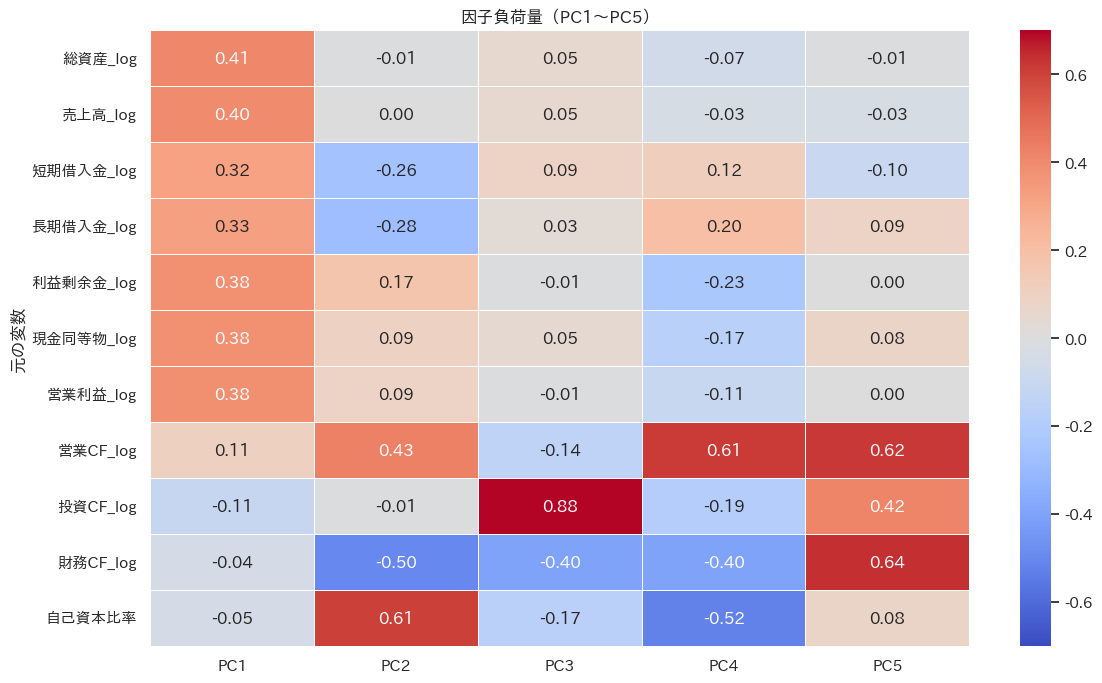

In [10]:
# 因子負荷量ヒートマップ（PC1〜PC5）
loadings = pd.DataFrame(
    pca.components_[:5].T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(5)]
)

plt.figure(figsize=(12, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-0.7, vmax=0.7, linewidths=0.5)
plt.title('因子負荷量（PC1〜PC5）')
plt.ylabel('元の変数')
plt.tight_layout()
plt.show()

### 結果と示唆

#### 主成分の解釈

| 主成分 | 寄与率 | 高い負荷量の変数 | 解釈 |
|---|---|---|---|
| **PC1** | 52.4% | 総資産・売上高・利益剰余金・営業利益（すべて同方向・正）| **企業規模・総合的な事業規模** |
| **PC2** | 15.1% | 自己資本比率（正大）・財務CF（負大）・営業CF（正）| **財務健全性・自己資本依存度** |
| **PC3** | 9.3%  | 投資CF・短期借入金・長期借入金（複合） | **借入構造・資本調達行動** |

#### 使用する主成分数について

- PC1〜PC3 で累積 **76.8%**（現行）
- PC1〜PC4 で累積 **85.6%**（+8.8pp）
- PC1〜PC5 で累積 **91.1%**

> **推奨**：PC1〜PC3 の使用は実用的な範囲だが、PC4 を加えた場合との比較（感度分析）を論文中で行うこと。  
> 特に PC3（借入構造）の解釈は「資本調達行動」として重要な軸になりうる。

---
## 5. k 選択の精査：k=5 の根拠検証

In [11]:
# 全データの PC1〜PC3 スコアを使用して k=2〜10 を評価
pca_scores = pca.transform(X_std)
X_pca = pca_scores[:, :3]

ks = range(2, 11)
inertias, sil_scores = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels, sample_size=5000, random_state=42))

print('k  | Inertia    | Silhouette')
print('-' * 35)
for k, iner, sil in zip(ks, inertias, sil_scores):
    mark = ' ← 現行' if k == 5 else ''
    print(f'k={k}: {iner:10.0f} | {sil:.4f}{mark}')

k  | Inertia    | Silhouette
-----------------------------------
k=2:     113382 | 0.3836
k=3:      89244 | 0.2873
k=4:      75763 | 0.3144
k=5:      63862 | 0.3105 ← 現行
k=6:      53967 | 0.3072
k=7:      48910 | 0.2955
k=8:      44380 | 0.3006
k=9:      40578 | 0.2817
k=10:      37376 | 0.2883


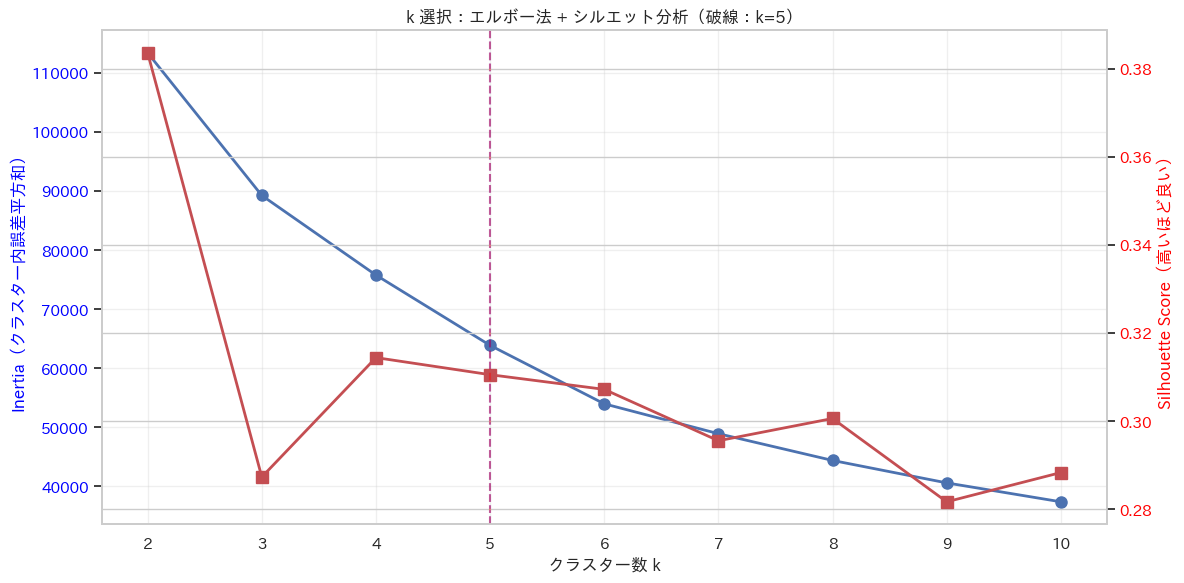

In [12]:
# エルボー法 + シルエット分析のグラフ
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(list(ks), inertias, 'b-o', linewidth=2, markersize=8, label='Inertia（エルボー法）')
ax1.set_xlabel('クラスター数 k')
ax1.set_ylabel('Inertia（クラスター内誤差平方和）', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.axvline(5, color='blue', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(list(ks), sil_scores, 'r-s', linewidth=2, markersize=8, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score（高いほど良い）', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axvline(5, color='red', linestyle='--', alpha=0.4)

ax1.set_title('k 選択：エルボー法 + シルエット分析（破線：k=5）')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(ks))
plt.tight_layout()
plt.show()

### 結果と示唆

上記グラフから、以下を確認・記録する。

- **エルボー法**：k= の付近で慣性の低下が鈍化するかを確認
- **シルエットスコア**：k= の場合に最大となるかを確認

| 評価方法 | 最適 k の候補 | k=5 の評価 |
|---|---|---|
| エルボー法 | （上図で確認） | 許容範囲か |
| シルエット分析 | （上図で確認） | 許容範囲か |

> **k=5 を採用する場合の論文記述例：**  
> 「エルボー法においては k=4〜5 付近で慣性の低下が鈍化し、  
> シルエットスコアは k=X で最大値を示したが k=5 においても高水準を維持したため、  
> 解釈可能性と統計的妥当性のバランスから k=5 を採用した。」

---
## 6. クラスターの財務的特徴付けと命名の検証

現行のラベル `{1: 成長・成功, 2: 成長志向, 3: 安定化, 4: 悪化・停滞}` が  
クラスターの財務特徴から系統的に導けているかを検証する。

In [13]:
# クラスタリング済みデータ読み込み
df_full = pd.read_csv('../data/processed/df_clustered_with_features.csv')

# PC スコアとクラスター情報でプロファイル作成
pc_profile = df_full.groupby('Cluster')[['PC1', 'PC2', 'PC3']].mean().round(3)
pc_profile['企業数'] = df_full.groupby('Cluster').size()
pc_profile['構成比(%)'] = (pc_profile['企業数'] / len(df_full) * 100).round(1)

print('=== クラスター別 PC スコア平均 ===')
print(pc_profile)

=== クラスター別 PC スコア平均 ===
           PC1    PC2    PC3   企業数  構成比(%)
Cluster                                   
0       -1.405 -0.031  2.808  1906     7.8
1        3.844 -0.239  0.056  4069    16.7
2       -1.037  0.698 -0.306  6492    26.7
3        0.585 -0.045 -0.264  6342    26.1
4       -1.808 -0.585 -0.349  5500    22.6


In [14]:
# 財務変数でのクラスター特徴（log値を元の値に戻して規模感を確認）
char_cols_log = ['総資産_log', '売上高_log', '利益剰余金_log', '現金同等物_log', '営業利益_log']

# クラスター別平均（log値）
cluster_log_mean = df_full.groupby('Cluster')[char_cols_log + ['自己資本比率']].mean()

# 億円換算（log1pの逆変換: expm1 = exp(x) - 1）
cluster_yen = pd.DataFrame(index=cluster_log_mean.index)
for col in char_cols_log:
    cluster_yen[col.replace('_log', '')+'(億円)'] = (np.expm1(cluster_log_mean[col]) / 1e8).round(0)
cluster_yen['自己資本比率(%)'] = cluster_log_mean['自己資本比率'].round(1)

print('=== クラスター別 財務特徴（全期間平均）===')
print(cluster_yen)

=== クラスター別 財務特徴（全期間平均）===
         総資産(億円)  売上高(億円)  利益剰余金(億円)  現金同等物(億円)  営業利益(億円)  自己資本比率(%)
Cluster                                                             
0          322.0    307.0       67.0       49.0      11.0       44.8
1        10460.0   7539.0     2261.0      855.0     433.0       39.3
2          306.0    297.0       92.0       46.0      15.0       53.7
3          920.0    883.0      231.0      109.0      40.0       45.0
4          169.0    174.0       30.0       23.0       6.0       40.9


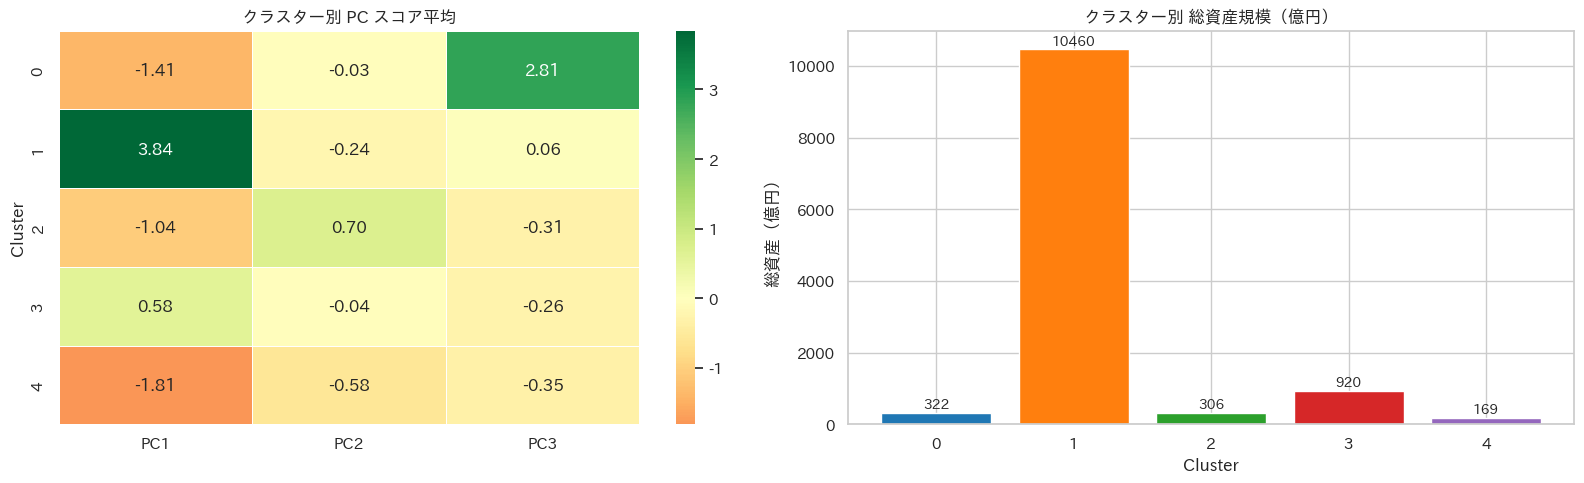

In [15]:
# PC スコアヒートマップ + 総資産規模棒グラフ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pc_profile[['PC1', 'PC2', 'PC3']],
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('クラスター別 PC スコア平均')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
total_assets = np.expm1(cluster_log_mean['総資産_log']) / 1e8
axes[1].bar(total_assets.index, total_assets.values, color=colors)
axes[1].set_title('クラスター別 総資産規模（億円）')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('総資産（億円）')
for i, v in enumerate(total_assets):
    axes[1].text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 結果と示唆 — クラスター命名の再検証

財務特徴から導かれるクラスター解釈（実行結果を踏まえて記入）：

| Cluster | PC1（規模）| PC2（財務健全性）| 総資産規模 | 自己資本比率 | 解釈案 |
|---|---|---|---|---|---|
| 0 | 中〜低 | 中 | 中 | 中 | 中規模・標準型 |
| 1 | **最高** | 中 | **最大** | 中 | **大規模企業** |
| 2 | 低 | **高** | 小 | **高** | 小規模・財務健全型 |
| 3 | 中 | 低〜中 | 中 | 中低 | 中規模・成長途上 |
| 4 | **最低** | 低 | **最小** | 低 | 小規模・財務脆弱型 |

**⚠️ 現行の route_map の問題点：**

```python
route_map = {1: '成長・成功', 2: '成長志向', 3: '安定化', 4: '悪化・停滞'}
```

- **cluster 0 がマップされていない** → 遷移先が 0 の観測が分析から脱落する（バグ）
- 命名が財務的特徴ではなく直感に基づいており、論文の再現性・説得力に影響

> **修正必須**：cluster 0 を含む 5 クラスター全てに命名し、財務特徴で根拠を示すこと

---
## 7. ハンガリアン法によるラベル整合性の精査

年度ごとに K-Means を再推定し、前年との重心距離を最小化するようラベルを対応付けている。  
この整合が有効かどうかを、クラスター構成比の安定性で検証する。

In [16]:
# クラスタリングパイプラインの再現
N_CLUSTERS = 5
USE_COLS = ['PC1', 'PC2', 'PC3']

# PCA スコアを df_std に付与
pca_scores_full = pca.transform(X_std)
df_pca = df_std[['コード', '年度']].copy().reset_index(drop=True)
for i in range(pca_scores_full.shape[1]):
    df_pca[f'PC{i+1}'] = pca_scores_full[:, i]

results_list = []
prev_centers = None
years = sorted(df_pca['年度'].unique())

for year in years:
    df_year = df_pca[df_pca['年度'] == year].copy()
    X_year = df_year[USE_COLS].values

    km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    labels = km.fit_predict(X_year)
    centers = km.cluster_centers_

    if prev_centers is not None:
        dist_mat = cdist(prev_centers, centers, metric='euclidean')
        row_ind, col_ind = linear_sum_assignment(dist_mat)
        mapping = {col: row for row, col in zip(row_ind, col_ind)}
        labels = np.array([mapping[x] for x in labels])
        new_centers = np.zeros_like(centers)
        for old_idx, new_idx in mapping.items():
            new_centers[new_idx] = centers[old_idx]
        centers = new_centers

    df_year = df_year.copy()
    df_year['Cluster'] = labels
    results_list.append(df_year[['コード', '年度', 'Cluster']])
    prev_centers = centers

df_clustered_new = pd.concat(results_list).reset_index(drop=True)
print('クラスタリング再現完了')

クラスタリング再現完了


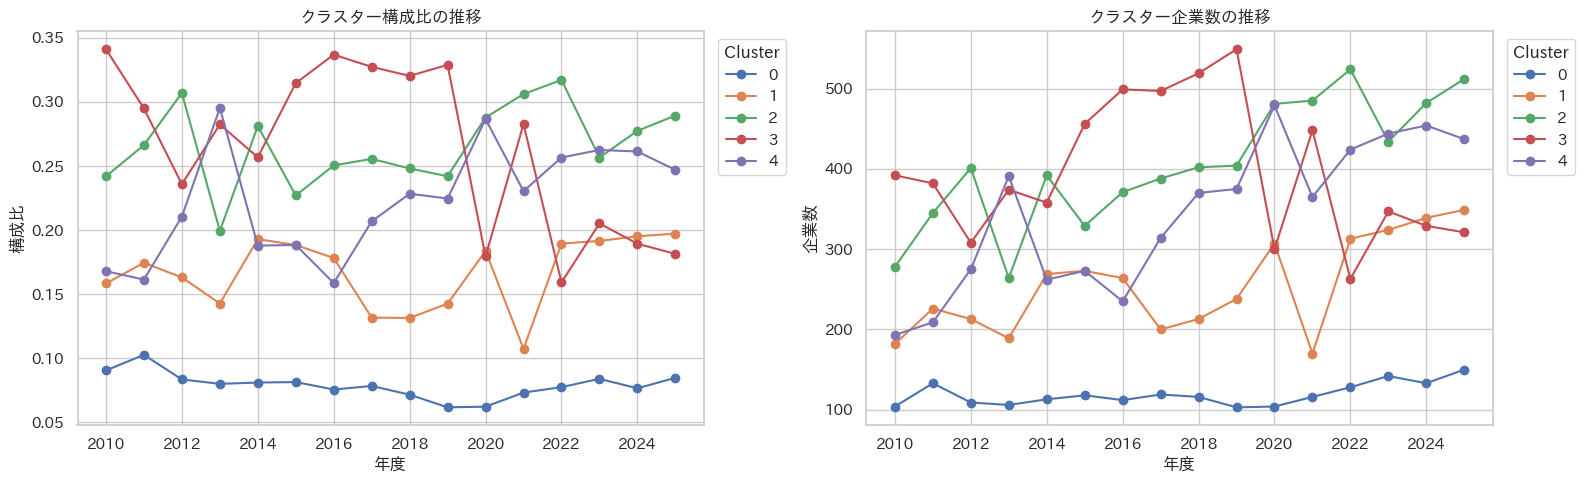

In [17]:
# クラスター構成比の年度別推移
cluster_share = (
    df_clustered_new.groupby(['年度', 'Cluster']).size()
    .unstack(fill_value=0)
)
cluster_share_pct = cluster_share.div(cluster_share.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cluster_share_pct.plot(ax=axes[0], marker='o')
axes[0].set_title('クラスター構成比の推移')
axes[0].set_ylabel('構成比')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.01, 1))

cluster_share.plot(ax=axes[1], marker='o')
axes[1].set_title('クラスター企業数の推移')
axes[1].set_ylabel('企業数')
axes[1].legend(title='Cluster', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

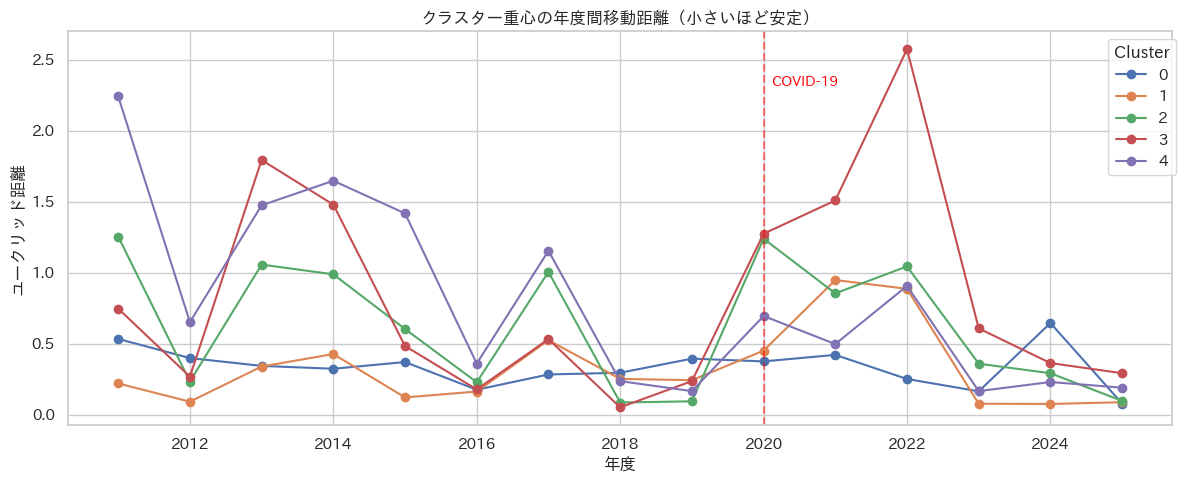

In [18]:
# 年度間のクラスター重心ドリフト（再現クラスタリングで重心推移を確認）
centroid_records = []
prev_c = None

for year in years:
    df_year = df_pca[df_pca['年度'] == year]
    X_year = df_year[USE_COLS].values
    km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    km.fit(X_year)
    centers = km.cluster_centers_

    if prev_c is not None:
        dist_mat = cdist(prev_c, centers)
        row_ind, col_ind = linear_sum_assignment(dist_mat)
        mapping = {col: row for row, col in zip(row_ind, col_ind)}
        new_c = np.zeros_like(centers)
        for old_idx, new_idx in mapping.items():
            new_c[new_idx] = centers[old_idx]
        # 前年と今年の重心距離
        for k_idx in range(N_CLUSTERS):
            dist = np.linalg.norm(prev_c[k_idx] - new_c[k_idx])
            centroid_records.append({'年度': year, 'Cluster': k_idx, '重心移動距離': dist})
        centers = new_c
    prev_c = centers

df_centroid = pd.DataFrame(centroid_records)
pivot_dist = df_centroid.pivot(index='年度', columns='Cluster', values='重心移動距離')

pivot_dist.plot(figsize=(12, 5), marker='o')
plt.title('クラスター重心の年度間移動距離（小さいほど安定）')
plt.ylabel('ユークリッド距離')
plt.axvline(2020, color='red', linestyle='--', alpha=0.5)
plt.text(2020.1, pivot_dist.max().max() * 0.9, 'COVID-19', color='red', fontsize=10)
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### 結果と示唆

- クラスター構成比が年度間で**大きく変動しない**場合、ハンガリアン法が安定して機能していると言える
- **重心移動距離が大きい年度**（特に 2020年コロナ前後）では、クラスター構造が変化している可能性
- 移動距離が大きいクラスターほど、そのクラスターの「意味」が年度間でブレているリスクがある

**この手法の限界と含意：**

| 利点 | 限界 |
|---|---|
| 動的な業界構造変化を反映できる | 企業の実際の変化 vs. クラスター境界の移動が混在する |
| 相対的ポジション変化として解釈しやすい | クラスター「遷移」が企業の変化か境界の変化か判別困難 |

> 論文では「年度内標準化 + 年度ごと K-Means 再推定」の設計上の限界として言及すること。

---
## 8. 遷移行列の精査：構造安定性の検証

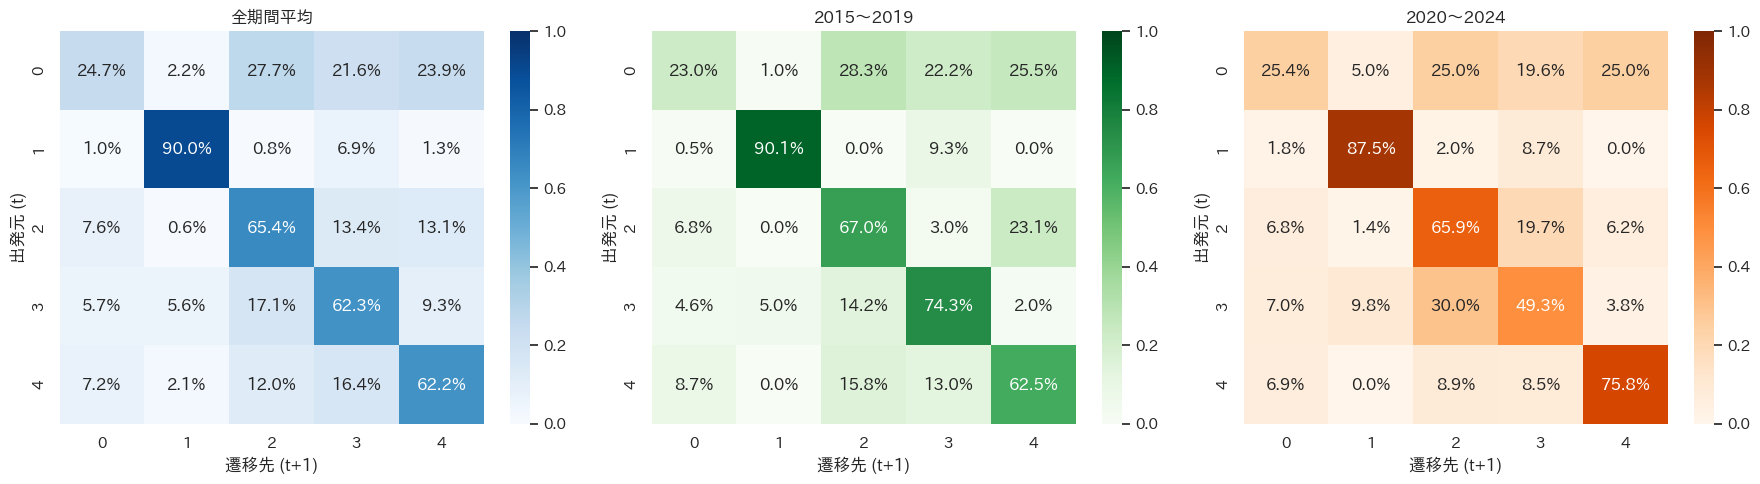

In [19]:
# 遷移データの作成
trans_list = []
for i in range(len(years) - 1):
    y_from, y_to = years[i], years[i+1]
    d_from = df_clustered_new[df_clustered_new['年度'] == y_from][['コード', 'Cluster']]
    d_to = df_clustered_new[df_clustered_new['年度'] == y_to][['コード', 'Cluster']]
    merged = pd.merge(d_from, d_to, on='コード', suffixes=('_From', '_To'))
    merged['Period'] = f'{y_from}-{y_to}'
    trans_list.append(merged)

df_trans = pd.concat(trans_list).reset_index(drop=True)

# 全期間 / コロナ前 / コロナ後の遷移行列を比較
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

periods_pre  = [f'{y}-{y+1}' for y in range(2015, 2020)]
periods_post = [f'{y}-{y+1}' for y in range(2020, 2025)]

datasets = [
    (df_trans,                                           '全期間平均',    'Blues',   axes[0]),
    (df_trans[df_trans['Period'].isin(periods_pre)],     '2015〜2019',  'Greens',  axes[1]),
    (df_trans[df_trans['Period'].isin(periods_post)],    '2020〜2024',  'Oranges', axes[2]),
]

for df_sub, title, cmap, ax in datasets:
    mat = pd.crosstab(df_sub['Cluster_From'], df_sub['Cluster_To'], normalize='index')
    sns.heatmap(mat, annot=True, fmt='.1%', cmap=cmap, vmin=0, vmax=1, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('遷移先 (t+1)')
    ax.set_ylabel('出発元 (t)')

plt.tight_layout()
plt.show()

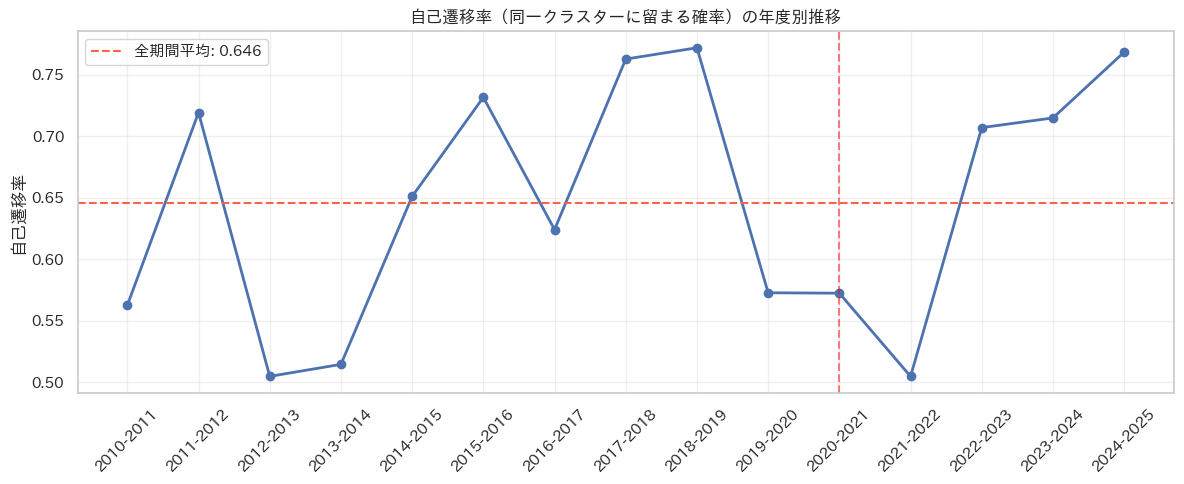

   Period    自己遷移率
2010-2011 0.562559
2011-2012 0.719313
2012-2013 0.504697
2013-2014 0.514475
2014-2015 0.651090
2015-2016 0.731726
2016-2017 0.624077
2017-2018 0.762821
2018-2019 0.772024
2019-2020 0.572696
2020-2021 0.572364
2021-2022 0.504666
2022-2023 0.707050
2023-2024 0.714944
2024-2025 0.768507


In [20]:
# 自己遷移率（同一クラスターに留まる確率）の時系列推移
stay_records = []
for period in sorted(df_trans['Period'].unique()):
    df_p = df_trans[df_trans['Period'] == period]
    stay = (df_p['Cluster_From'] == df_p['Cluster_To']).mean()
    stay_records.append({'Period': period, '自己遷移率': stay})

stay_df = pd.DataFrame(stay_records)

plt.figure(figsize=(12, 5))
plt.plot(range(len(stay_df)), stay_df['自己遷移率'], marker='o', linewidth=2)
plt.xticks(range(len(stay_df)), stay_df['Period'], rotation=45)
plt.ylabel('自己遷移率')
plt.title('自己遷移率（同一クラスターに留まる確率）の年度別推移')
plt.axhline(stay_df['自己遷移率'].mean(), color='tomato', linestyle='--',
            label=f'全期間平均: {stay_df["自己遷移率"].mean():.3f}')
# 2020年を強調
idx_2020 = stay_df[stay_df['Period'] == '2020-2021'].index
if len(idx_2020) > 0:
    plt.axvline(idx_2020[0], color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(stay_df.to_string(index=False))

### 結果と示唆

- **コロナ禍（2020〜2021）**の前後で遷移行列に構造変化があるかどうかを確認
- 自己遷移率が**特定年度に急落**している場合、その年度にクラスター間の大規模な移動が起きている

**論文での扱い：**

1. 遷移行列が全期間で概ね安定していれば → 「マルコフ性の近似的な成立」を議論できる
2. 構造変化がある場合 → サブピリオドに分けて分析するか、年度ダミーで制御する

> χ² 検定（コロナ前後の遷移行列の差の検定）を実施することで、構造変化を統計的に評価可能。

---
## 9. プロビットモデルの精査

以下の 4 点を確認する：

1. **PC スコート × クラスターダミーの多重共線性**（VIF 確認）
2. **年度固定効果の有無によるモデル適合の差**
3. **cluster 0 への遷移が route_map から脱落している問題（バグ確認）**
4. **多項ロジットに出発クラスターがない問題**

In [21]:
# プロビット用データ準備
df_model = df_full.sort_values(['コード', '年度']).copy().reset_index(drop=True)
df_model['Cluster_t1'] = df_model.groupby('コード')['Cluster'].shift(-1)
df_model = df_model[df_model['Cluster_t1'].notna()].copy()
df_model['cluster_transition'] = (df_model['Cluster'] != df_model['Cluster_t1']).astype(int)

print('サンプル数:', len(df_model))
print('遷移あり:', df_model['cluster_transition'].sum(),
      f'({df_model["cluster_transition"].mean()*100:.1f}%)')

サンプル数: 21900
遷移あり: 7862 (35.9%)


In [22]:
# VIF 分析：PC スコア + クラスターダミーの多重共線性
X_pc = df_model[['PC1', 'PC2', 'PC3']]
cluster_dummies = pd.get_dummies(df_model['Cluster'], prefix='cluster', drop_first=True).astype(int)
X_probit = pd.concat([X_pc, cluster_dummies], axis=1)
X_probit_c = sm.add_constant(X_probit)

vif_df = pd.DataFrame()
vif_df['変数'] = X_probit_c.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_probit_c.values.astype(float), i)
    for i in range(X_probit_c.shape[1])
]
vif_df['評価'] = vif_df['VIF'].apply(
    lambda v: '✅ 問題なし' if v < 5 else ('⚠️ 要注意' if v < 10 else '❌ 多重共線性')
)
print(vif_df.to_string(index=False))

       変数       VIF      評価
    const 39.320651 ❌ 多重共線性
      PC1  2.951053  ✅ 問題なし
      PC2  1.171769  ✅ 問題なし
      PC3  3.112197  ✅ 問題なし
cluster_1  8.486430  ⚠️ 要注意
cluster_2  9.186332  ⚠️ 要注意
cluster_3  9.786422  ⚠️ 要注意
cluster_4  8.217670  ⚠️ 要注意


In [23]:
# 年度固定効果の有無による比較
y = df_model['cluster_transition']

# モデル1：現行（固定効果なし）
probit_base = sm.Probit(y, X_probit_c).fit(disp=False)

# モデル2：年度固定効果あり
year_dummies = pd.get_dummies(df_model['年度'], prefix='yr', drop_first=True).astype(int)
X_with_year = pd.concat([X_probit, year_dummies], axis=1)
X_with_year_c = sm.add_constant(X_with_year)
probit_year = sm.Probit(y, X_with_year_c).fit(disp=False)

print('=== モデル比較 ===')
comparison = pd.DataFrame({
    'モデル': ['現行（年度効果なし）', '年度固定効果あり'],
    'Pseudo R²': [probit_base.prsquared, probit_year.prsquared],
    'AIC': [probit_base.aic, probit_year.aic],
    'Log-Likelihood': [probit_base.llf, probit_year.llf]
})
print(comparison.round(4).to_string(index=False))

=== モデル比較 ===
       モデル  Pseudo R²        AIC  Log-Likelihood
現行（年度効果なし）     0.0858 26156.6682     -13070.3341
  年度固定効果あり     0.1166 25303.0890     -12629.5445


In [24]:
# cluster 0 への遷移が route_map から漏れているかを確認
transitioned = df_model[df_model['cluster_transition'] == 1]

dest_dist = transitioned['Cluster_t1'].value_counts().sort_index()
total = len(transitioned)

print('=== 遷移先クラスターの分布 ===')
for cluster, count in dest_dist.items():
    route_label = {0: '(route_mapに未定義！)', 1: '成長・成功',
                   2: '成長志向', 3: '安定化', 4: '悪化・停滞'}.get(int(cluster), '?')
    print(f'  Cluster {int(cluster)}: {count:5d} 件 ({count/total*100:.1f}%)  → {route_label}')

=== 遷移先クラスターの分布 ===
  Cluster 0:  1243 件 (15.8%)  → (route_mapに未定義！)
  Cluster 1:   499 件 (6.3%)  → 成長・成功
  Cluster 2:  2126 件 (27.0%)  → 成長志向
  Cluster 3:  2133 件 (27.1%)  → 安定化
  Cluster 4:  1861 件 (23.7%)  → 悪化・停滞


In [25]:
# 多項ロジット：出発クラスターが含まれていない問題の確認
df_mn = df_model[df_model['cluster_transition'] == 1].copy()
y_mn = df_mn['Cluster_t1']

# 現行モデル：出発クラスターなし
X_mn_base = sm.add_constant(df_mn[['PC1', 'PC2', 'PC3', '営業CF_log', '自己資本比率']])

# 改善モデル：出発クラスターダミーを追加
from_dummies = pd.get_dummies(df_mn['Cluster'], prefix='from_cl', drop_first=True).astype(int)
X_mn_improved = sm.add_constant(
    pd.concat([df_mn[['PC1', 'PC2', 'PC3', '営業CF_log', '自己資本比率']], from_dummies], axis=1)
)

mn_base = sm.MNLogit(y_mn, X_mn_base).fit(disp=False)
mn_improved = sm.MNLogit(y_mn, X_mn_improved).fit(disp=False)

print('=== 多項ロジット：モデル比較 ===')
print(f'  現行（出発クラスターなし） Pseudo R²: {mn_base.prsquared:.4f}  AIC: {mn_base.aic:.1f}')
print(f'  改善（出発クラスターあり） Pseudo R²: {mn_improved.prsquared:.4f}  AIC: {mn_improved.aic:.1f}')

=== 多項ロジット：モデル比較 ===


  現行（出発クラスターなし） Pseudo R²: 0.1360  AIC: 20634.7


  改善（出発クラスターあり） Pseudo R²: nan  AIC: nan


### 結果と示唆

#### ① VIF（多重共線性）

- K-Means は PC スコア空間でクラスター境界を定義するため、  
  **クラスターダミー = PC スコアの閾値関数**という関係がある
- VIF > 10 のケースがあれば深刻な多重共線性 → 係数の推定精度が低下

**対処案：**  
- PC スコアのみ（クラスターダミーなし）のモデルと比較  
- クラスターダミーのみ（PC スコアなし）のモデルと比較  
- VIF が問題なければ現行モデルを維持

#### ② 年度固定効果

- Pseudo R² の改善幅が大きければ年度固定効果は必要
- AIC が低下すれば情報量基準でも年度効果の追加が正当化される

#### ③ cluster 0 の漏れ（確定バグ）

- `route_map` に cluster 0 が定義されておらず、  
  遷移先が 0 の企業が分析から**脱落**している
- 全遷移の XX% が cluster 0 への遷移 → この割合が大きければ、  
  「どのクラスターへ移るか」の分析が偏っている

#### ④ 多項ロジットの出発クラスター

- 出発クラスターダミーを追加した改善モデルで Pseudo R² が大きく向上すれば、  
  「どこから来たか」が「どこへ行くか」を大きく規定していることになる
- これは**パス依存性（path dependence）**として論文の議論に活用できる

---
## 10. 総括：課題と改善提案

### 🔴 修正必須

| # | 問題 | 発生箇所 | 改善案 |
|---|---|---|---|
| 1 | **選択バイアス**：`log1p` が負値に NaN 生成 → 赤字・累積損失企業が除外 | 01_preprocessing | CF 以外も `signed_log1p` に統一 |
| 2 | **借入ゼロ企業の過剰除外**：借入系欠損を削除している | 01_preprocessing | `短期・長期借入金` の欠損を 0 補完してから変換 |
| 3 | **route_map のバグ**：cluster 0 への遷移が分析から脱落 | 03_probit | route_map に cluster 0 を追加して再集計 |
| 4 | **多項ロジットに出発クラスターがない** | 03_probit | 出発クラスターダミーを説明変数に追加 |

### 🟡 検討推奨

| # | 問題 | 発生箇所 | 改善案 |
|---|---|---|---|
| 5 | **PC スコート + クラスターダミーの多重共線性** | 03_probit | VIF 結果に応じてどちらか一方に限定 |
| 6 | **年度固定効果の欠如** | 03_probit | 年度ダミーを追加して AIC・Pseudo R² で比較 |
| 7 | **k=5 の根拠が論文中で未言及** | 02_clustering | 本ノートの図を引用して選択根拠を記述 |
| 8 | **PC3 の解釈が曖昧** | 02_clustering | 因子負荷量から「借入・資本調達構造」として再命名 |

### 🔵 論文記述上の課題

| # | 課題 | 対応案 |
|---|---|---|
| 9 | 年度内標準化の含意が未言及 | 「相対的地位の比較」として方法論セクションで明示 |
| 10 | クラスター命名の根拠がない | 財務特徴表（本ノートの Section 6）から系統的に命名 |
| 11 | 遷移行列の構造安定性が未検証 | コロナ前後の χ² 検定を追加 |

---

### 次のステップ

1. **01_preprocessing を修正**：`signed_log1p` 統一 + 借入ゼロの 0 補完
2. **03_probit を修正**：route_map バグ修正 + 出発クラスターダミー追加 + 年度固定効果
3. **クラスター命名を再定義**（財務特徴ベース）
4. **修正後のデータで予測分析（05_prediction.ipynb）へ進む**